# Mathematics Primer


In [1]:
# Load required Python libraries.
import matplotlib.pyplot as plt
import numpy as np
from scipy import linalg
from matplotlib import cm

## Eigenvalues and Quadratic Programs

**Main Idea**: By looking at an unconstrained quadratic optimization problem, we will see how the eigenvalues tell us about the curvature (second derivatives) and help us classify the stationary points.

**Reference**: Section *2.2.2 Quadratic Forms* in Biegler (2010)

![Book](../../media/quad1.png)

### Analysis Algorithm

We will start by defining a function for our classification procedure.

In [2]:
# The main event
def quad_analyze(c, a, B):
    """
    Analyze the stationary points of a quadratic objective.

    Inputs:
        c - offset (scalar)
        a - linear coefficients (vector)
        B - quadratic coefficients (matrix)

    Outputs:
        None

    Displayed:
        1. Inputs
        2. Eigenvalues and eigenvectors
        3. Stationary point (transformed coordinates)
        4. Stationary point (original coordinates)
        5. Function value and gradient at stationary point
        6. 3D plot
    """

    ### Display inputs
    print("***Inputs***")
    print("c = ", c, "\n")
    print("a = ", a, "\n")
    print("B = \n", B, "\n")

    ### Eigendecomposition
    print("***Eigendecomposition***")
    l, V = linalg.eig(B)
    print("Lambda = \n", np.diag(l), "\n")
    print("V = \n", V, "\n")

    ### Calculate stationary point
    n = len(a)
    zstar = np.zeros(n)

    abar = (V.transpose()).dot(a)
    print("abar = \n", abar, "\n")

    # Loop over dimensions
    for j in range(0, n):
        # If eigenvalue is NOT zero
        ##
        # Previous code
        # if(l[j] != 0):
        ##
        # More stable version
        if abs(l[j]) > 1e-8:
            zstar[j] = -abar[j] / np.real(l[j])

        # Otherwise check if abar is nonzero
        elif abar[j] != 0:
            print("WARNING: No stationary point exists.")

    xstar = V.dot(zstar)

    print("***(Possible) Stationary Point in Transformed Coordinates:")
    print("z* = ", zstar, "\n")

    print("***(Possible) Stationary Point in Original Coordinates:")
    print("x* = ", xstar, "\n")

    ### Check function value and gradient
    fval = c + a.dot(xstar) + 0.5 * xstar.dot(B.dot(xstar))
    grad = a + xstar.dot(B)

    print("***Checking function and gradient***")
    print("f(x*) = ", fval)
    print("f'(x*) = \n", grad, "\n")

    ### Make 3D plot
    # Tutorial: https://matplotlib.org/mpl_toolkits/mplot3d/tutorial.html
    if n == 2:
        # Create vectors in both dimensions
        dx = 5
        x1 = np.arange(xstar[0] - dx, xstar[0] + dx, 0.25)
        x2 = np.arange(xstar[1] - dx, xstar[1] + dx, 0.25)

        # Create a matrix of all points to sample
        X1, X2 = np.meshgrid(x1, x2)
        n1 = len(x1)
        n2 = len(x2)
        F = np.zeros([n2, n1])
        xtemp = np.zeros(2)
        for i in range(0, n1):
            xtemp[0] = x1[i]
            for j in range(0, n2):
                xtemp[1] = x2[j]
                F[j, i] = c + a.dot(xtemp) + 0.5 * xtemp.dot(B.dot(xtemp))

        # Create 3D figure
        fig = plt.figure()
        ax = fig.add_subplot(projection="3d")

        # Plot f(x). viridis is monotone in luminance, so the surface still
        # reads when the handout is printed in black and white. See
        # figures/README.md: coolwarm is not allowed for this reason.
        ax.plot_surface(X1, X2, F, linewidth=0, cmap=cm.viridis, antialiased=True)

        # Add (possible) stationary point
        ax.scatter(xstar[0], xstar[1], fval, s=50, color="#D55E00", depthshade=True)

        # Draw vertical line through stationary point to help visualization
        # Maximum value in array
        fmax = np.amax(F)
        fmin = np.amin(F)
        ax.plot(
            [xstar[0], xstar[0]], [xstar[1], xstar[1]], [fmin, fmax], color="#D55E00"
        )

        ax.set_xlabel("$x_1$")
        ax.set_ylabel("$x_2$")
        ax.set_zlabel("$f(x)$")

        plt.show()

### Exercise 2.8 in Biegler (2010)

***Inputs***
c =  0 

a =  [1 1] 

B = 
 [[2 1]
 [1 2]] 

***Eigendecomposition***
Lambda = 
 [[3.+0.j 0.+0.j]
 [0.+0.j 1.+0.j]] 

V = 
 [[ 0.70710678 -0.70710678]
 [ 0.70710678  0.70710678]] 

abar = 
 [1.41421356 0.        ] 

***(Possible) Stationary Point in Transformed Coordinates:
z* =  [-0.47140452 -0.        ] 

***(Possible) Stationary Point in Original Coordinates:
x* =  [-0.33333333 -0.33333333] 

***Checking function and gradient***
f(x*) =  -0.3333333333333333
f'(x*) = 
 [2.22044605e-16 2.22044605e-16] 



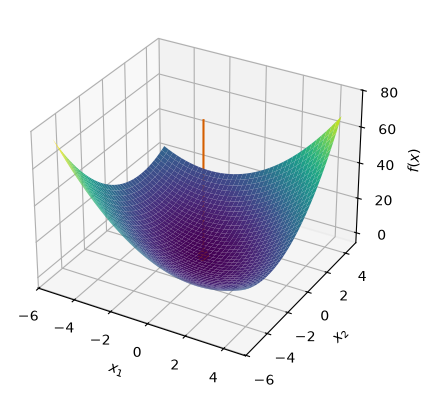

In [3]:
c = 0
a = np.array([1, 1])
B = np.array([[2, 1], [1, 2]])

quad_analyze(c, a, B)

### Activity 1

Classify the stationary point for $f(x) = x_1 + x_2$.

***Inputs***
c =  0 

a =  [1 1] 

B = 
 [[0. 0.]
 [0. 0.]] 

***Eigendecomposition***
Lambda = 
 [[0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j]] 

V = 
 [[1. 0.]
 [0. 1.]] 

abar = 
 [1. 1.] 

***(Possible) Stationary Point in Transformed Coordinates:
z* =  [0. 0.] 

***(Possible) Stationary Point in Original Coordinates:
x* =  [0. 0.] 

***Checking function and gradient***
f(x*) =  0.0
f'(x*) = 
 [1. 1.] 



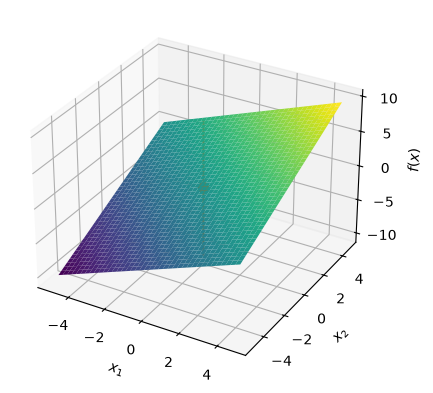

In [4]:
### BEGIN SOLUTION
c = 0
a = np.array([1, 1])
B = np.zeros([2, 2])

quad_analyze(c, a, B)
### END SOLUTION

### Activity 2

Classify the stationary point for $f(x) = x_1^2 + x_2^2 - 2x_1 x_2 + 0 x_1 - 0 x_2 + 3$.

Hint: $B$ needs to be symmetric.

***Inputs***
c =  3 

a =  [0 0] 

B = 
 [[ 2 -2]
 [-2  2]] 

***Eigendecomposition***
Lambda = 
 [[4.0000000e+00+0.j 0.0000000e+00+0.j]
 [0.0000000e+00+0.j 4.4408921e-16+0.j]] 

V = 
 [[ 0.70710678  0.70710678]
 [-0.70710678  0.70710678]] 

abar = 
 [0. 0.] 

***(Possible) Stationary Point in Transformed Coordinates:
z* =  [-0.  0.] 

***(Possible) Stationary Point in Original Coordinates:
x* =  [0. 0.] 

***Checking function and gradient***
f(x*) =  3.0
f'(x*) = 
 [0. 0.] 



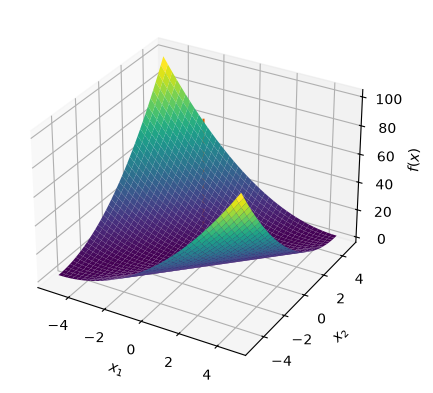

In [5]:
### BEGIN SOLUTION
c = 3

# Updated the function
a = np.array([0, 0])
# Note: If these are non-zero then no stationary point exists

B = 2 * np.array([[1, -1], [-1, 1]])

quad_analyze(c, a, B)
### END SOLUTION

## Classifying Functions (Key Concepts from Real Analysis)

## Taylor Series Approximation

## Finite Difference Approximation

**Main Idea**: This example complements the in-class example where we use Taylor series expansions to estimate truncation error for forward, backward, and central finite difference formulas. We will revisit finite difference formulas again in a few lectures.

Consider the following test function:
$$ f(x) = e^{x} $$

with

$$f'(x) = e^{x}$$

In [6]:
# Define the test function
def my_f(x):
    return np.exp(x)


# Specify point to examine
a = 1.0

# Calculate function value at x = a
fa = my_f(a)

# Calculate exact first derivative at x=1
df1 = my_f(a)  # Need to replace if you consider a different test function!

# Generate values for epsilon
eps = np.power(10, np.arange(-16, 1, 0.25))
n = len(eps)

### Forward Finite Difference

$$ f'_f(a) = \frac{f(a+\epsilon) - f(a)}{\epsilon} $$

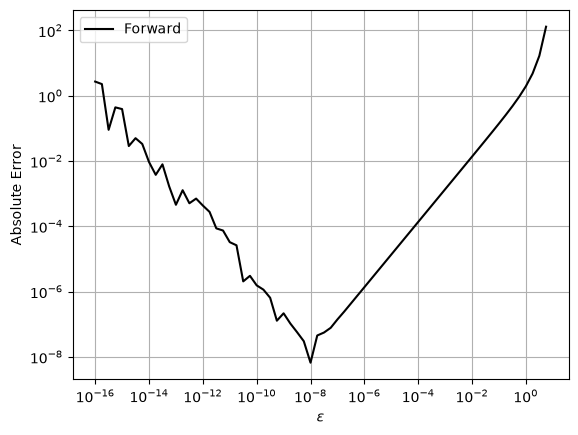

In [7]:
# Preallocate error array
error_forward = np.zeros(n)

# Calculate finite difference approximation and error
for i in range(0, n):
    df1_forward = (my_f(a + eps[i]) - fa) / eps[i]
    error_forward[i] = abs(df1_forward - df1)

# Plot
plt.figure()
plt.loglog(eps, error_forward, label="Forward", color="black", linestyle="-")
plt.xlabel(r"$\epsilon$")
plt.ylabel("Absolute Error")
plt.legend()
plt.grid()
plt.show()

### Backward Finite Difference

$$ f'_b(a) = \frac{f(a) - f(a - \epsilon)}{\epsilon} $$

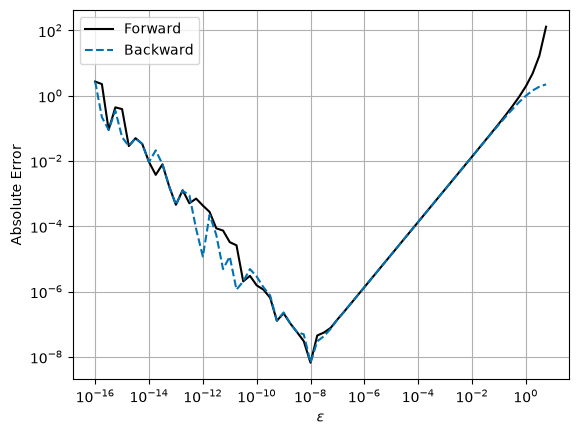

In [8]:
# Preallocate error array
error_backward = np.zeros(n)

# Calculate finite difference approximation and error
for i in range(0, n):
    df1_backward = (fa - my_f(a - eps[i])) / eps[i]
    error_backward[i] = abs(df1_backward - df1)

# Plot
plt.figure()
plt.loglog(eps, error_forward, label="Forward", color="black", linestyle="-")
plt.loglog(eps, error_backward, label="Backward", color="#0072B2", linestyle="--")
plt.xlabel(r"$\epsilon$")
plt.ylabel("Absolute Error")
plt.grid()
plt.legend()
plt.show()

### Central Finite Difference

$$ f'_c(a) = \frac{f(a+\epsilon) - f(a - \epsilon)}{2 \epsilon} $$

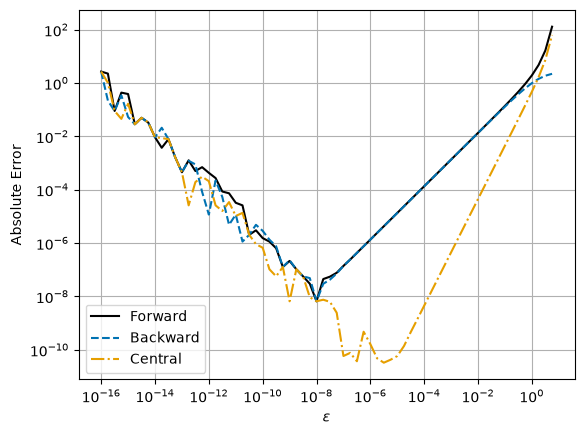

In [9]:
# Preallocate error array
error_central = np.zeros(n)

# Calculate finite difference approximation and error
for i in range(0, n):
    df1_central = (my_f(a + eps[i]) - my_f(a - eps[i])) / (2 * eps[i])
    error_central[i] = abs(df1_central - df1)

# Plot
plt.figure()
plt.loglog(eps, error_forward, label="Forward", color="black", linestyle="-")
plt.loglog(eps, error_backward, label="Backward", color="#0072B2", linestyle="--")
plt.loglog(eps, error_central, label="Central", color="#E69F00", linestyle="-.")
plt.xlabel(r"$\epsilon$")
plt.ylabel("Absolute Error")
plt.grid()
plt.legend()
plt.show()

### Activity
1. Record the results for the test function $f(x) = e^x$ at $x=1$.
2. Try the point $x=10$ and record the results.
3. Try a different test function.

#### Original: $f(x) = e^{x}$ at $x=1$

**Forward**: Lowest absolute error of $10^{-8}$ at $\epsilon$ = $10^{-8}$

**Backward**: Lowest absolute error of $10^{-8}$ at $\epsilon$ = $10^{-8}$

**Central**: Lowest absolute error of $10^{-10}$ at $\epsilon$ = $10^{-6}$


#### Variant: $f(x) = e^{x}$ at $x=10$

**Forward**: Lowest absolute error of $10^{-4}$ at $\epsilon$ = $10^{-8}$

**Backward**: Lowest absolute error of $10^{-4}$ at $\epsilon$ = $10^{-8}$

**Central**: Lowest absolute error of $10^{-6}$ at $\epsilon$ = $10^{-5}$

#### Your own test function

**Forward**: Lowest absolute error of ... at $\epsilon$ = ...

**Backward**: 

**Central**:

#### Discussion

Are there any general trends from these (limited) computational experiments?

What is the best $\epsilon$ for an arbitrary function?